# EDA 02 — How does uncertainty vary by variable type?

**Question (README, Phase 1 Step 5):** At the *same* geography level, why are some variables far less reliable than others?

**Plain-English setup.** [Notebook 01](01-cv-by-geography-size.ipynb) showed that at tract level, reliability differs enormously across variables: total population is fine (median CV 0.08), poverty is shaky (0.38), and small subgroup counts are near-noise (≈0.9). This notebook shows the **mechanism**: the ACS samples a similar share of households everywhere, so the *number of people behind an estimate* determines its relative precision. Small counts → few sampled people → big relative noise. If that mechanism holds, CV should fall roughly as $1/\sqrt{\text{estimate}}$ — a straight line of slope −½ on a log-log plot.

Along the way we build the project's first **derived estimate**: the six Black 65+ sex×age cells combined into one number with a properly-aggregated MOE (the deferred step from the ingestion phase). Definitions in [`docs/glossary.md`](../docs/glossary.md); shared formulas with citations in [`analysis/acs.py`](../analysis/acs.py).

**Data.** ACS 5-year vintage 2024, New Jersey, **tract level only** (n = 2,181) — the smallest geography where every variable is published. Regenerate with `python ingestion/pull_acs_nj.py`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Notebook lives in /notebooks; the analysis package lives at the repo root.
REPO_ROOT = Path.cwd() if (Path.cwd() / "analysis").is_dir() else Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))
from analysis import acs

tract = acs.load_level("tract")
assert len(tract) == 2181, f"expected 2,181 tracts, got {len(tract)}"

# Same exclusion as notebook 01: top-coded income is censored, not measured.
topcoded = acs.flag_topcoded_income(tract)
assert int(topcoded.sum()) == 41, f"expected 41 top-coded tracts, got {int(topcoded.sum())}"
print(f"Tracts: {len(tract):,} | top-coded income rows excluded from income CVs: {int(topcoded.sum())}")

Tracts: 2,181 | top-coded income rows excluded from income CVs: 41


## 1. Why single subgroup cells can't be analyzed one at a time

Notebook 01 flagged that the six Black 65+ cells are mostly zeros at tract level. Here is the full picture — the share of tracts where each cell is zero (a zero count has no CV, so each single cell describes only a minority of tracts):

In [2]:
zero_share = pd.DataFrame({
    "cell": [acs.VARIABLES[c] for c in acs.BLACK_65PLUS_CELLS],
    "nonzero tracts": [int((tract[f"{c}E"] > 0).sum()) for c in acs.BLACK_65PLUS_CELLS],
    "zero tracts": [int((tract[f"{c}E"] == 0).sum()) for c in acs.BLACK_65PLUS_CELLS],
})
zero_share["% of tracts zero"] = (100 * zero_share["zero tracts"] / len(tract)).round(1)
zero_share

,cell,nonzero tracts,zero tracts,% of tracts zero
0,Black male 65-74,1088,1093,50.1
1,Black male 75-84,622,1559,71.5
2,Black male 85+,244,1937,88.8
3,Black female 65-74,1101,1080,49.5
4,Black female 75-84,842,1339,61.4
5,Black female 85+,514,1667,76.4


## 2. Building the derived estimate: Black 65+ as one number

The Census-documented way to combine estimates is to sum them and combine their MOEs by **root-sum-of-squares**:

$$MOE_{agg} = \sqrt{\textstyle\sum_i MOE_i^2}$$

with one refinement that matters a lot here: **when more than one component estimate is zero, include only the largest zero-cell MOE, once.** Zero-estimate MOEs are near-identical placeholder values, and root-sum-squaring several of them overstates the combined uncertainty. *Source for both: "Understanding and Using American Community Survey Data: What All Data Users Need to Know," Ch. 8 (Calculating Measures of Error for Derived Estimates).* With 50–89% of tracts at zero per cell, the refinement is not a technicality — the sensitivity table below shows its effect. Both variants are implemented (with citations) in [`analysis/acs.py`](../analysis/acs.py); the zero rule is our default.

This is a **derived estimate** — a number we computed, not one the Bureau published. It is labeled as such everywhere it appears.

In [3]:
agg = pd.DataFrame(index=tract.index)
agg["estimate"] = acs.aggregate_estimate(tract, acs.BLACK_65PLUS_CELLS)
agg["moe"] = acs.aggregate_moe(tract, acs.BLACK_65PLUS_CELLS)  # handbook zero rule (default)
agg["moe_plain_rss"] = acs.aggregate_moe(tract, acs.BLACK_65PLUS_CELLS, zero_rule=False)
agg["cv"] = acs.cv(agg["estimate"], agg["moe"])
agg["cv_plain_rss"] = acs.cv(agg["estimate"], agg["moe_plain_rss"])

# The derived estimate must be exactly the sum of its parts,
# and the zero rule can only shrink the MOE, never grow it.
assert agg["estimate"].equals(tract[[f"{c}E" for c in acs.BLACK_65PLUS_CELLS]].sum(axis=1))
assert (agg["moe"].dropna() <= agg["moe_plain_rss"].dropna() + 1e-9).all()

nonzero = agg["estimate"] > 0
print(f"Tracts where all six cells are zero (aggregate = 0, no CV possible): "
      f"{int((~nonzero).sum())} ({(~nonzero).mean():.1%})")

sensitivity = pd.DataFrame(
    {
        "median MOE (nonzero tracts)": [
            agg.loc[nonzero, "moe"].median(), agg.loc[nonzero, "moe_plain_rss"].median()],
        "median CV": [agg["cv"].median(), agg["cv_plain_rss"].median()],
        "% of nonzero tracts CV > 0.30": [
            100 * (agg.loc[nonzero, "cv"] > 0.30).mean(),
            100 * (agg.loc[nonzero, "cv_plain_rss"] > 0.30).mean()],
    },
    index=["handbook zero rule (our default)", "plain RSS (all six MOEs)"],
).round(3)
sensitivity

Tracts where all six cells are zero (aggregate = 0, no CV possible): 585 (26.8%)


,median MOE (nonzero tracts),median CV,% of nonzero tracts CV > 0.30
handbook zero rule (our default),49.412,0.631,87.469
plain RSS (all six MOEs),56.178,0.714,87.845


### What the sensitivity table says

The zero rule trims the aggregate MOE by a **median of 10% (up to 55%)** in nonzero tracts, moving the median aggregate CV from 0.714 (plain RSS) to **0.631**. Direction and size are exactly what the handbook predicts: plain RSS double-counts placeholder uncertainty from empty cells. We adopt the handbook rule; the comparison stays here so the choice and its impact are on the record.

Aggregation also buys **coverage**: the combined 65+ estimate is nonzero in 73% of tracts, where the individual cells were usable in only 11–50% of tracts each.

## 3. Chart A — reliability by variable type, same tracts, same survey

Chart saved to data\processed\eda02_cv_by_variable_type.png (local-only, regenerable)


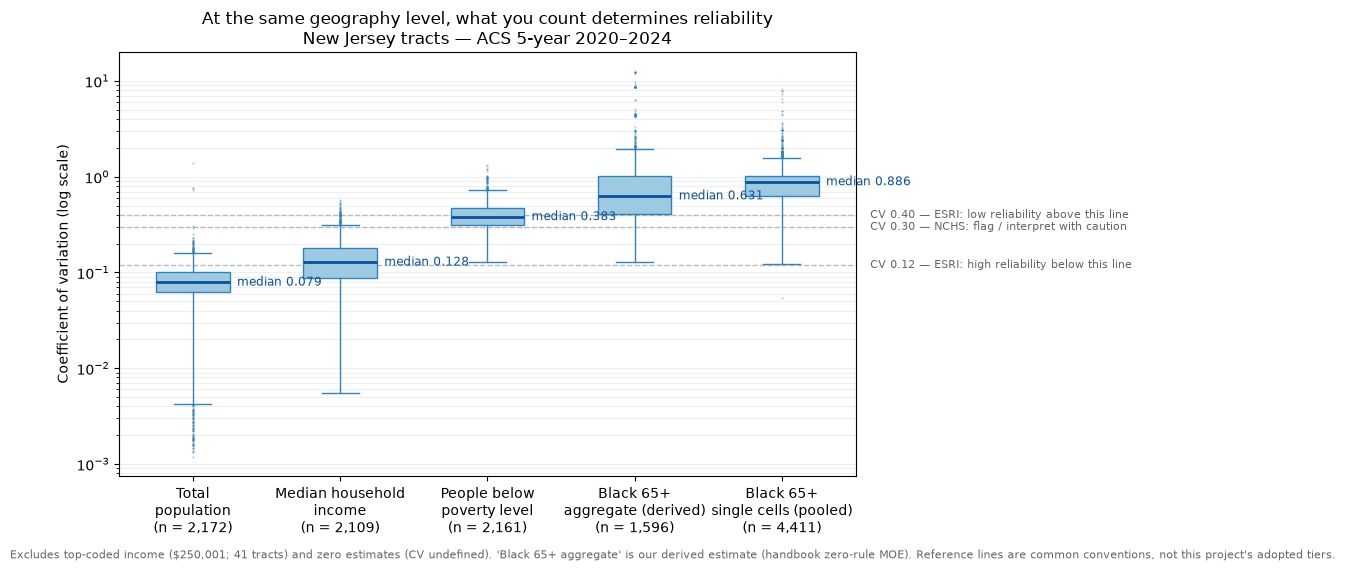

In [4]:
income_cv = acs.cv(tract["B19013_001E"], tract["B19013_001M"])[~topcoded]
pop_cv = acs.cv(tract["B01003_001E"], tract["B01003_001M"])
pov_cv = acs.cv(tract["B17001_002E"], tract["B17001_002M"])
single_cv = pd.concat(
    [acs.cv(tract[f"{c}E"], tract[f"{c}M"]) for c in acs.BLACK_65PLUS_CELLS],
    ignore_index=True,
)

series = [
    ("Total\npopulation", pop_cv.dropna()),
    ("Median household\nincome", income_cv.dropna()),
    ("People below\npoverty level", pov_cv.dropna()),
    ("Black 65+\naggregate (derived)", agg["cv"].dropna()),
    ("Black 65+\nsingle cells (pooled)", single_cv.dropna()),
]
data = [s.to_numpy() for _, s in series]
tick_labels = [f"{name}\n(n = {len(s):,})" for name, s in series]

fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.boxplot(
    data,
    tick_labels=tick_labels,
    patch_artist=True,
    boxprops=dict(facecolor="#9ecae1", edgecolor="#3182bd"),
    medianprops=dict(color="#08519c", linewidth=2),
    whiskerprops=dict(color="#3182bd"),
    capprops=dict(color="#3182bd"),
    flierprops=dict(marker=".", markersize=3, markerfacecolor="#3182bd",
                    markeredgecolor="none", alpha=0.4),
)
ax.set_yscale("log")
ax.set_axisbelow(True)
ax.grid(axis="y", which="both", alpha=0.2)

for y, label in [
    (0.12, "CV 0.12 — ESRI: high reliability below this line"),
    (0.30, "CV 0.30 — NCHS: flag / interpret with caution"),
    (0.40, "CV 0.40 — ESRI: low reliability above this line"),
]:
    ax.axhline(y, color="#bbbbbb", linestyle="--", linewidth=1, zorder=0)
    ax.text(1.02, y, label, transform=ax.get_yaxis_transform(),
            fontsize=8, va="center", color="#666666")

for i, d in enumerate(data, start=1):
    med = float(np.median(d))
    ax.text(i + 0.3, med, f"median {med:.3f}", fontsize=8.5,
            va="center", color="#08519c")

ax.set_ylabel("Coefficient of variation (log scale)")
ax.set_title(
    "At the same geography level, what you count determines reliability\n"
    "New Jersey tracts — ACS 5-year 2020–2024",
    fontsize=12,
)
fig.text(
    0.01, -0.04,
    r"Excludes top-coded income (\$250,001; 41 tracts) and zero estimates (CV undefined). "
    "'Black 65+ aggregate' is our derived estimate (handbook zero-rule MOE). "
    "Reference lines are common conventions, not this project's adopted tiers.",
    fontsize=8, color="#666666",
)

out = REPO_ROOT / "data" / "processed" / "eda02_cv_by_variable_type.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=200, bbox_inches="tight")
print(f"Chart saved to {out.relative_to(REPO_ROOT)} (local-only, regenerable)")
plt.show()

### Reading Chart A

Five variables from the same survey, in the same 2,181 tracts, spanning **an order of magnitude in typical reliability** — median CV 0.079 (population) to 0.886 (single subgroup cells). The derived aggregate lands where the formula says it should: meaningfully better than the single cells (median 0.631 vs. 0.886, a 1.4× improvement, plus far better coverage) — **but still far above every reference line.** Aggregating the six cells does *not* rescue tract-level subgroup analysis: 87% of nonzero tracts remain above CV 0.30. The honest fit-for-use conclusion is that small-subgroup counts need a bigger geography (county) or a bigger cell definition, not clever post-processing.

## 4. Chart B — the mechanism

If relative noise is driven by how many people stand behind an estimate, CV should fall along a slope of −½ on a log-log plot of CV against estimate size ($CV \propto 1/\sqrt{N}$, the signature of sampling noise).

**Median household income sits this chart out:** it is not a count. Its precision is governed by how many households were sampled and the shape of the local income distribution — a \$200k-median tract is not "bigger" than a \$60k one, so estimate magnitude says nothing about its sample.

Chart saved to data\processed\eda02_cv_vs_estimate_size.png (local-only, regenerable)


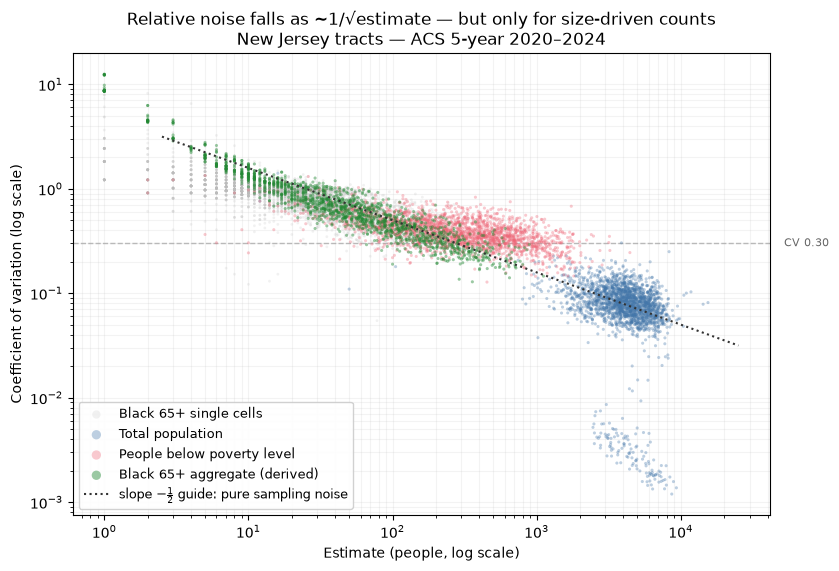

In [5]:
cells_e = pd.concat([tract[f"{c}E"] for c in acs.BLACK_65PLUS_CELLS], ignore_index=True)
cells_cv = single_cv  # already pooled in the same order

fig, ax = plt.subplots(figsize=(9, 6))
series_b = [
    ("Black 65+ single cells", cells_e, cells_cv, "#bbbbbb", 0.20, 4),
    ("Total population", tract["B01003_001E"], pop_cv, "#4477AA", 0.35, 5),
    ("People below poverty level", tract["B17001_002E"], pov_cv, "#EE6677", 0.35, 5),
    ("Black 65+ aggregate (derived)", agg["estimate"], agg["cv"], "#228833", 0.45, 5),
]
for name, e, c, color, alpha, size in series_b:
    e, c = e.reset_index(drop=True), c.reset_index(drop=True)
    m = (e > 0) & c.notna()
    ax.scatter(e[m], c[m], s=size, color=color, alpha=alpha, label=name,
               edgecolors="none")

guide_x = np.logspace(0.4, 4.4, 50)
ax.plot(guide_x, 5.0 / np.sqrt(guide_x), color="#333333", linestyle=":",
        linewidth=1.5, label=r"slope $-\frac{1}{2}$ guide: pure sampling noise")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_axisbelow(True)
ax.grid(which="both", alpha=0.15)
ax.axhline(0.30, color="#bbbbbb", linestyle="--", linewidth=1, zorder=0)
ax.text(1.02, 0.30, "CV 0.30", transform=ax.get_yaxis_transform(),
        fontsize=8, va="center", color="#666666")

leg = ax.legend(loc="lower left", fontsize=9, framealpha=0.9, markerscale=3)
ax.set_xlabel("Estimate (people, log scale)")
ax.set_ylabel("Coefficient of variation (log scale)")
ax.set_title(
    "Relative noise falls as ~1/√estimate — but only for size-driven counts\n"
    "New Jersey tracts — ACS 5-year 2020–2024",
    fontsize=12,
)

out = REPO_ROOT / "data" / "processed" / "eda02_cv_vs_estimate_size.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
print(f"Chart saved to {out.relative_to(REPO_ROOT)} (local-only, regenerable)")
plt.show()

In [6]:
def loglog_slope(e, c):
    e, c = e.reset_index(drop=True), c.reset_index(drop=True)
    m = (e > 0) & c.notna()
    return float(np.polyfit(np.log10(e[m]), np.log10(c[m]), 1)[0])

slopes = {
    "Total population": loglog_slope(tract["B01003_001E"], pop_cv),
    "People below poverty level": loglog_slope(tract["B17001_002E"], pov_cv),
    "Black 65+ aggregate (derived)": loglog_slope(agg["estimate"], agg["cv"]),
}
print("Fitted log-log slopes (pure 1/√N sampling noise would be -0.50):")
for name, s in slopes.items():
    print(f"  {name:<30} {s:+.2f}")

# Guard the notebook's claims.
assert agg["cv"].median() < single_cv.median(), "aggregation should improve the median CV"
assert slopes["Total population"] < -0.3, "population should track the sampling-noise slope"
assert slopes["Black 65+ aggregate (derived)"] < -0.3, "aggregate should track the sampling-noise slope"
assert slopes["People below poverty level"] > slopes["Total population"], \
    "poverty should be flatter than population (prevalence-driven, not size-driven)"

Fitted log-log slopes (pure 1/√N sampling noise would be -0.50):
  Total population               -0.47
  People below poverty level     -0.18
  Black 65+ aggregate (derived)  -0.51


### A surprise in Chart B, flagged before moving on

The bottom-right of Chart B shows a **detached cluster of tracts** whose population CVs are 10–40× better than the main cloud. House rule: characterize a surprise, don't smooth over it.

In [7]:
low = pop_cv < 0.02
cluster = tract[low]
print(f"Tracts with population CV < 0.02: {len(cluster)} "
      f"(spread across {cluster['COUNTY'].nunique()} of 21 counties)")
print(f"Cluster population MOE: min {cluster['B01003_001M'].min():.0f}, "
      f"median {cluster['B01003_001M'].median():.0f}, max {cluster['B01003_001M'].max():.0f}")
print(f"Main-cloud median population MOE: "
      f"{tract.loc[~low & pop_cv.notna(), 'B01003_001M'].median():.0f}")
print(f"Cluster population sizes are ordinary: "
      f"{cluster['B01003_001E'].min():,.0f} to {cluster['B01003_001E'].max():,.0f}")
cluster[["NAME", "B01003_001E", "B01003_001M"]].head(5)

Tracts with population CV < 0.02: 131 (spread across 21 of 21 counties)
Cluster population MOE: min 14, median 21, max 143
Main-cloud median population MOE: 546
Cluster population sizes are ordinary: 2,459 to 9,321


,NAME,B01003_001E,B01003_001M
26,Census Tract 106; Atlantic County; New Jersey,4400,21
27,Census Tract 107; Atlantic County; New Jersey,5832,15
33,Census Tract 112.02; Atlantic County; New Jersey,7103,21
34,Census Tract 113; Atlantic County; New Jersey,4520,24
77,Census Tract 22; Bergen County; New Jersey,5288,81


**What we know:** 131 tracts (6% of NJ) publish total-population MOEs of ±14–143 people against a statewide median of ±546 — near-controlled precision, but with a published MOE rather than the controlled-estimate annotation — and they appear in every one of NJ's 21 counties, with ordinary population sizes. **What we don't know: why.** Candidate explanations (sub-county effects of ACS population controls; group-quarters populations sourced from administrative records) need official confirmation, so this is logged as a question for the Census mentors rather than guessed at. Practical implication if it holds up: reliability can be **bimodal within a single variable at a single geography level** — one more argument for a per-estimate score over blanket rules like "tracts are noisy."

## 5. Findings

**What did we find?** The mechanism is confirmed — with one important exception.

- **Size-driven counts follow the sampling-noise law almost exactly.** Fitted log-log slopes: total population **−0.47**, the Black 65+ aggregate **−0.51**, against a theoretical −0.50 for pure $1/\sqrt{N}$ sampling noise. For these variables, *how many people the estimate represents* is nearly all you need to predict its reliability.
- **Poverty breaks the pattern (slope −0.18).** A larger poverty count usually means a *poorer tract*, not a bigger survey sample, so magnitude buys poverty far less reliability than it buys population. This is why poverty was the shocker in Notebook 01 (80% of tracts above CV 0.30): its reliability is capped by prevalence, and no amount of "pick a bigger tract" fixes it.
- **Aggregation helps, but cannot rescue tract-level subgroup analysis.** Combining the six 65+ cells (with the handbook's zero-cell rule — median 10% MOE reduction vs. plain RSS, up to 55%) improves the median CV from 0.886 to 0.631 and extends coverage from 11–50% of tracts (single cells) to 73%. Yet 87% of nonzero tracts still sit above the CV 0.30 caution line.
- **Unexplained: 131 tracts with near-controlled population precision** (MOE ±14–143 vs. median ±546), in all 21 counties. Cause unknown — logged as a mentor question, not guessed at.

**Why does it matter to the Census Bureau?** Two design requirements for the composite score fall straight out of this notebook. First, **estimate magnitude is a strong, nearly free predictor of reliability for count variables** — a score could exploit it even where MOEs are missing. Second, **variable type must enter the score on its own**, because prevalence-driven variables like poverty defy the size law: two estimates of identical magnitude can have wildly different reliability depending on *what* they measure. A score built on geography size alone would systematically overstate the reliability of poverty-type variables. And for fit-for-use guidance: subgroup analysis below county level should be steered toward bigger cell definitions or bigger geographies — post-hoc aggregation is not a cure.

**What next?**
- **EDA 03 — the choropleth:** where is unreliability concentrated? Income and poverty variants (the poverty map may be the stronger mentor chart, given its story here).
- The Notebook 01 chart + Chart A here are the current two-chart candidate set for the July 22 biweekly; Chart B is the backup for a methods-minded audience.